# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

d = np.genfromtxt('../../labs/05/data/claym2.csv', delimiter=',', names=True)
#NETID = 'claym2'   # <-- set this
#d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

28 epochs over 895 days; median quoted error 2.18 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


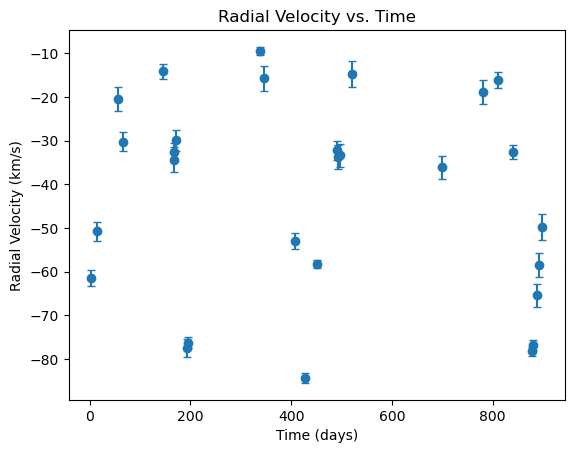

In [2]:
plt.errorbar(t, rv, yerr=sig, fmt='o', capsize=3)
plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs. Time")
plt.show()

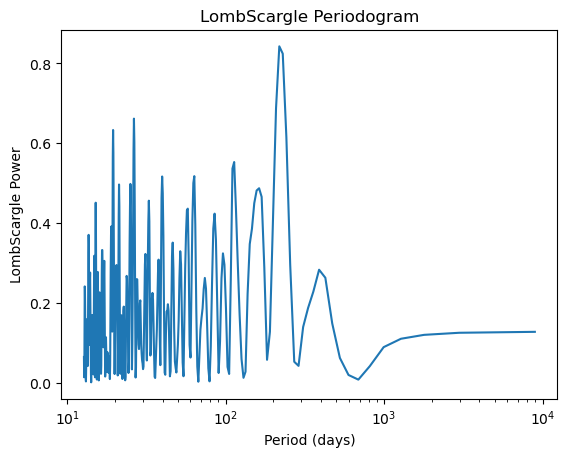

In [3]:
frequency, power = LombScargle(t, rv, sig).autopower()
period = 1 / frequency

plt.plot(period, power)
plt.xlabel("Period (days)")
plt.ylabel("LombScargle Power")
plt.title("LombScargle Periodogram")
plt.xscale("log") #looks a little easier to read
plt.show()

In [4]:
best_indices = np.argsort(power)[-10:][::-1]

best_periods = []
for i in best_indices[:3]:
    best_periods.append(period[i])
    print(f"Period = {period[i]:.2f} days, Power = {power[i]:.3f}")

best_periods

Period = 218.23 days, Power = 0.843
Period = 229.43 days, Power = 0.824
Period = 208.08 days, Power = 0.687


[np.float64(218.23463414634145),
 np.float64(229.42615384615382),
 np.float64(208.08418604651163)]

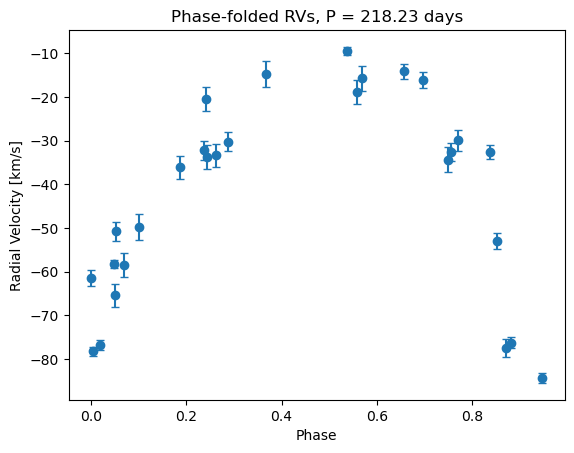

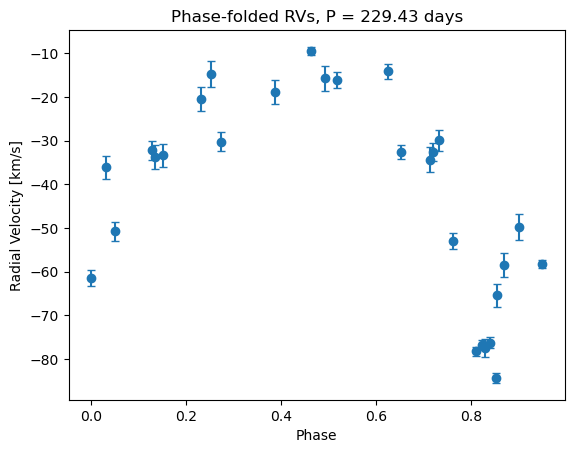

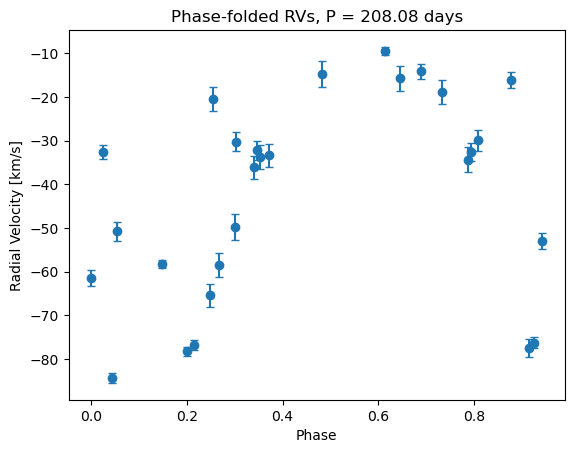

In [5]:
for i in best_periods:    
    phase = ((t - t.min()) / i) % 1
    
    plt.figure()
    plt.errorbar(phase, rv, yerr=sig, fmt="o", capsize=3)
    plt.xlabel("Phase")
    plt.ylabel("Radial Velocity [km/s]")
    plt.title(f"Phase-folded RVs, P = {i:.2f} days")
    plt.show()

**ANSWER (a few sentences):**

Although these three seem to be a peak, there are a few characteristics between them that would only have me label two as peaks. The first graph have a very strong peak that makes a clear arch. Secondly, the points are tightly packed together along said arch. The second graph has similar characteristics, but the ends are a little more spread apart. The last peak, I do not think is a period. It is not tightly packed through any part of the peak and the points are spread around. This is likely error. The sin function appears to more accurately apply to the first two peak periods, less so for the last one. I think there are two positions in the data where these data are valid. There is slightly more scatter among the second and third, but I believe the scatter in three is much worse at aligning witht he observations.

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___, $\gamma = $ ___ $\pm$ ___ km/s, jitter $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$. Is your companion a black-hole candidate? One sentence.


/var/folders/1_/x9v87_qs7_nb9mx28cmcd1c80000gn/T/ipykernel_33789/1635693773.py:82: OptimizeWarning: Initial guess is not within the specified bounds
  result2 = minimize(
You must install the tqdm library to use progress indicators with emcee


Best maximum-likelihood fit [P, K, e, omega, Tp, gamma, ln(s)]:
[222.23018041  34.65010354   0.45649205   2.64244335 -25.60036955
 -35.34284068   0.96122792]
Best log-likelihood: -74.685
Runner-up log-likelihood: -104.309

Prior choices:
P: uniform over a broad interval around each plausible period; positive periods only.
K: uniform positive semi-amplitude, bounded to exclude implausibly large values.
e: uniform from 0 to 0.95; eccentricity must be physical.
omega: uniform over a centered 2*pi interval to avoid cutting the angular mode.
Tp: uniform within half a period of the best-fit epoch; Tp is defined modulo P.
gamma: uniform over a broad interval covering the observed velocities.
ln(s): uniform over a broad interval; sampling log jitter guarantees s > 0.

Integrated autocorrelation times:
P: 74.3 steps
K: 76.9 steps
e: 71.6 steps
omega: 72.3 steps
Tp: 72.4 steps
gamma: 71.5 steps
ln(s): 71.4 steps
Chain length / tau: 130.0


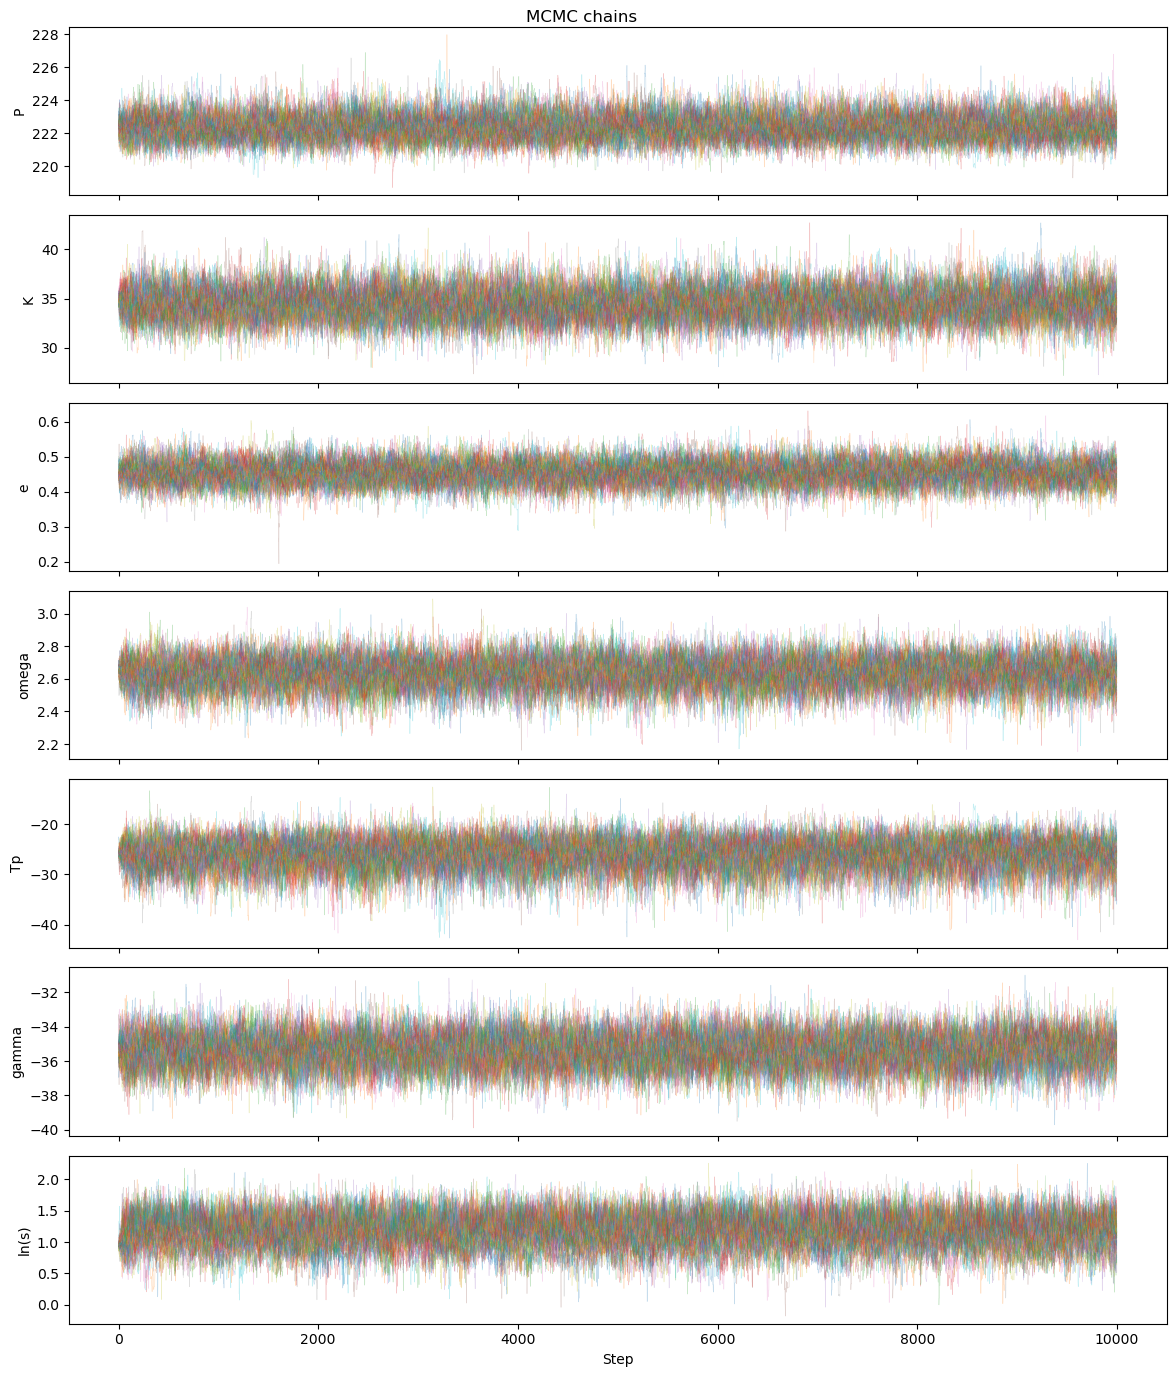


Burn-in: 230 steps; thinning: every 35 steps
Retained posterior samples: 17856

Posterior median and 68% credible interval:
P (days): 222.31 -0.611 +0.668
K (km/s): 34.419 -1.31 +1.34
e: 0.45431 -0.0273 +0.0269
omega (rad): 2.6387 -0.0792 +0.0749
Tp (days): -25.847 -2.67 +2.4
gamma (km/s): -35.378 -0.835 +0.812
s (km/s): 3.2251 -0.657 +0.782
f(M) (solar masses): 0.66447 -0.0685 +0.0718
The mass function is computed sample-by-sample because it is nonlinear in P, K, and e,
and their posterior correlations affect its uncertainty.
Black-hole candidate by the lab's f(M) > 3 solar-mass criterion? False


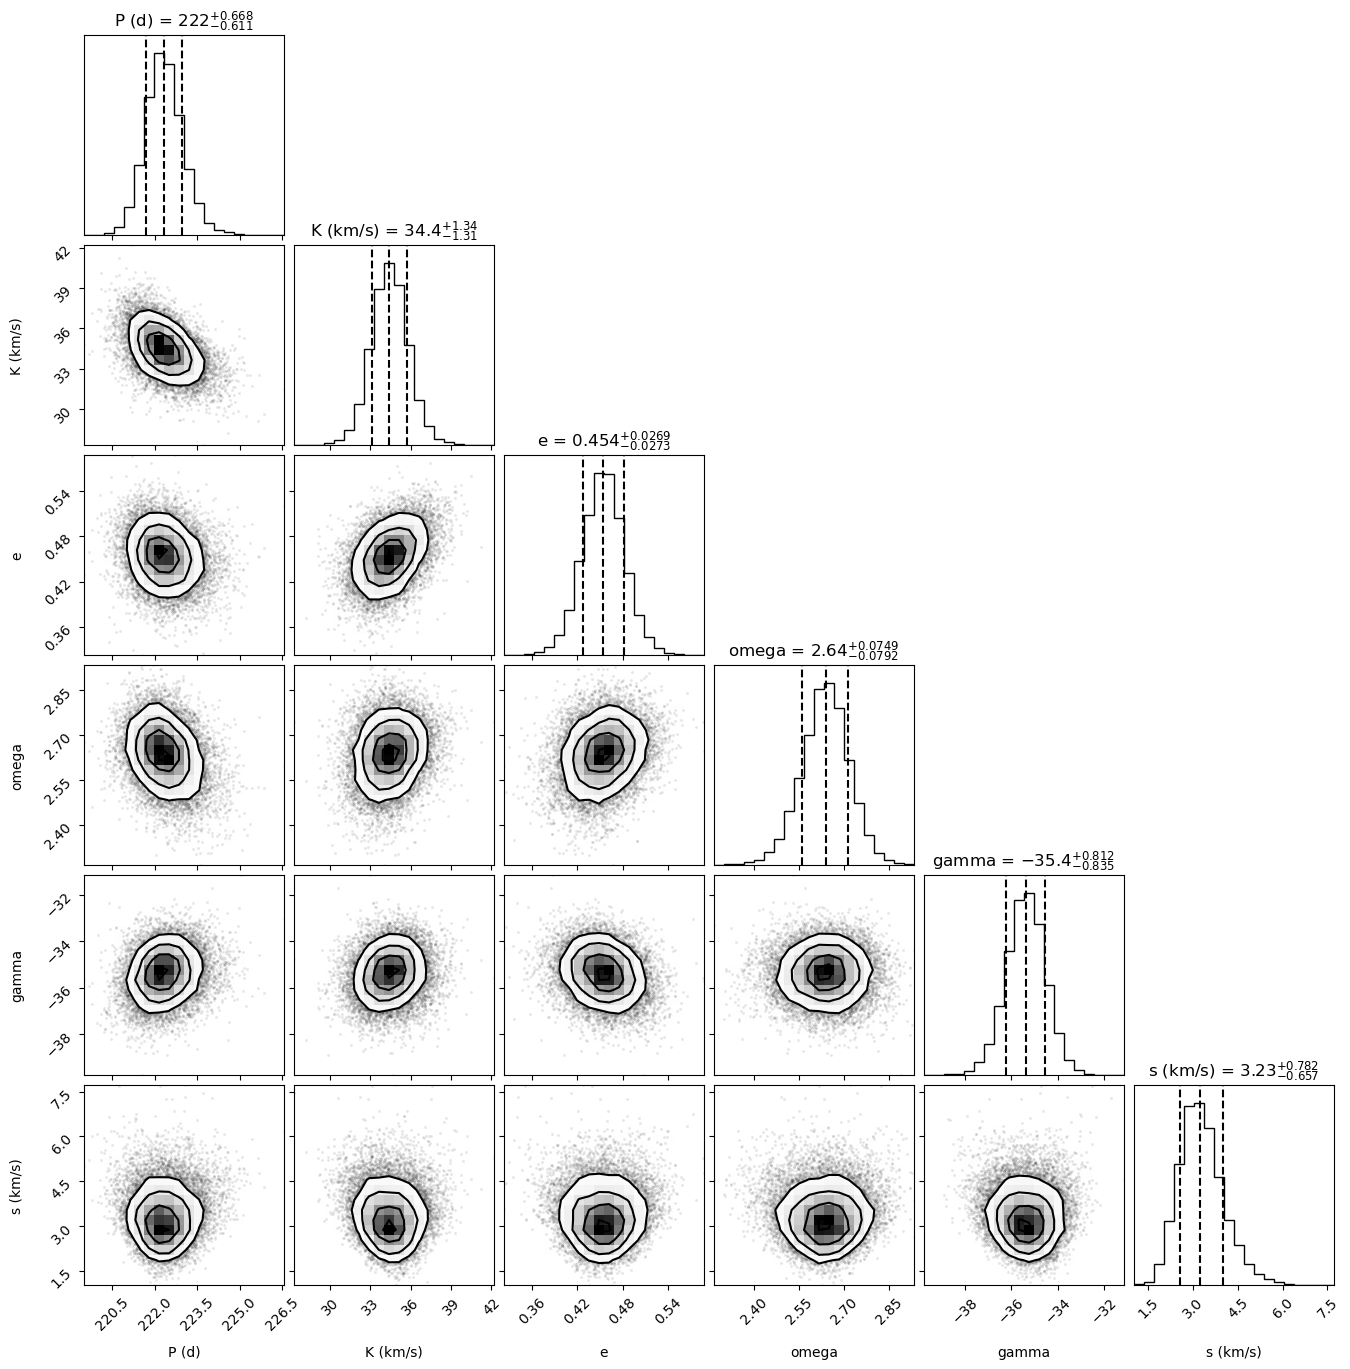

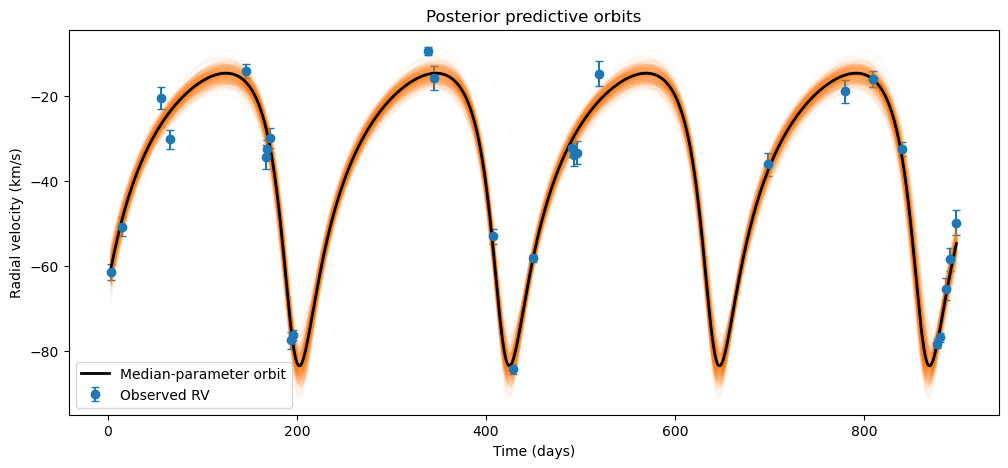

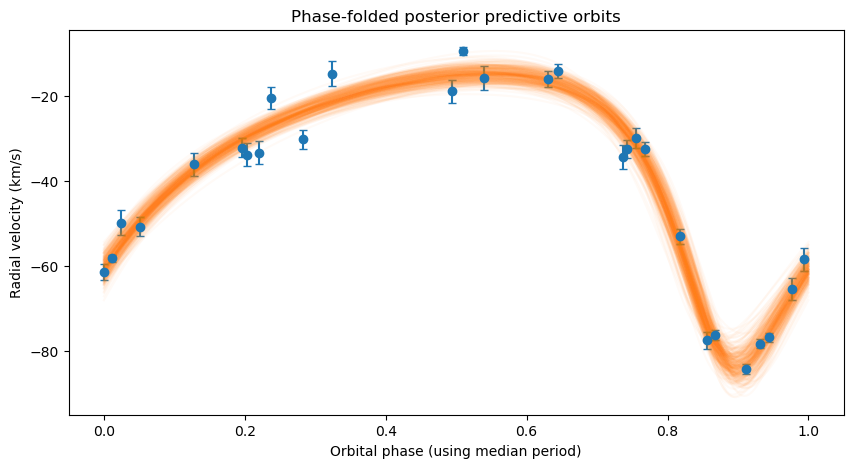

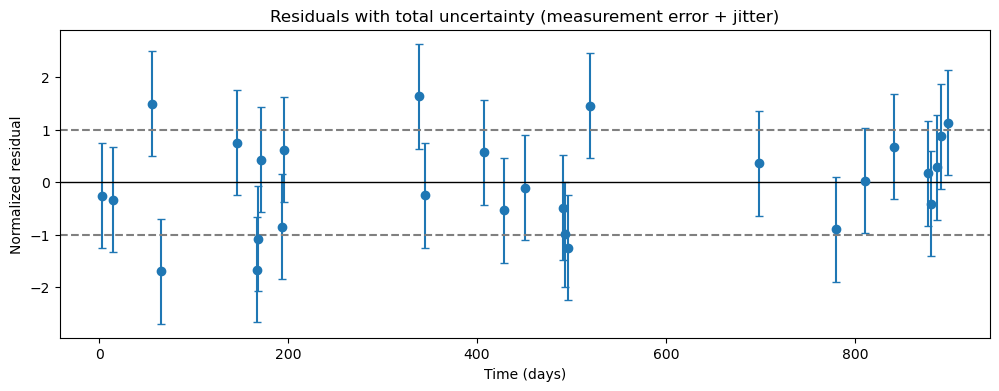

Normalized residual RMS: 0.907
Check for residual trends, clustering, or large outliers before concluding that the remaining scatter is noise.


In [6]:

# PART 2: Sample the posterior with emcee
# Uses the data, kepler_rv(), mass_function(), and best_periods from above.

import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize

np.random.seed(42)

# ---------- 1. Set bounds and define the log-likelihood ----------

rv_range = np.ptp(rv)
gamma0 = np.median(rv)
K_max = max(5 * rv_range, 10.0)
gamma_min, gamma_max = rv.min() - rv_range, rv.max() + rv_range
ln_s_min, ln_s_max = np.log(0.01), np.log(max(2 * rv_range, 10.0))

def log_likelihood(theta):
    P, K, e, omega, Tp, gamma, ln_s = theta
    if P <= 0 or K <= 0 or not 0 <= e < 1:
        return -np.inf
    if not np.isfinite(ln_s) or abs(ln_s) > 700:
        return -np.inf

    s = np.exp(ln_s)
    model = kepler_rv(t, P, K, e, omega, Tp, gamma)
    var = sig**2 + s**2

    return -0.5 * np.sum((rv - model)**2 / var + np.log(var) + np.log(2*np.pi))


# ---------- 2. Maximum-likelihood search over candidate periods ----------
# Try several omega and Tp starting values for every Part 1 candidate.

candidates = np.unique(np.asarray(best_periods, dtype=float))
fits = []

for P0 in candidates:
    if P0 <= 0:
        continue

    # Search locally around each candidate period.
    bounds = [
        (max(0.1, 0.5 * P0), 1.5 * P0),
        (0.001, K_max),
        (0.0, 0.95),
        (-np.inf, np.inf),  # centered below for each start
        (t.min() - P0/2, t.min() + P0/2),
        (gamma_min, gamma_max),
        (ln_s_min, ln_s_max)
    ]

    for omega0 in [0, np.pi/2, np.pi, 3*np.pi/2]:
        for phase in np.linspace(0, 1, 4, endpoint=False):
            Tp0 = t.min() + phase * P0
            x0 = [P0, max(rv_range/2, 0.1), 0.3,
                  omega0, Tp0, gamma0, np.log(max(np.median(sig), 0.1))]

            # Use an omega interval centered on this starting angle.
            local_bounds = bounds.copy()
            local_bounds[3] = (omega0 - np.pi, omega0 + np.pi)

            result = minimize(
                lambda x: -log_likelihood(x),
                x0,
                method="Nelder-Mead",
                options={"maxiter": 6000, "xatol": 1e-7, "fatol": 1e-7}
            )

            # Enforce physical/global bounds after unconstrained optimization.
            x = result.x.copy()
            x[0] = np.clip(x[0], bounds[0][0] + 1e-7, bounds[0][1] - 1e-7)
            x[1] = np.clip(x[1], 1e-6, K_max - 1e-6)
            x[2] = np.clip(x[2], 0, 0.95)
            x[4] = np.clip(x[4], bounds[4][0], bounds[4][1])
            x[5] = np.clip(x[5], gamma_min, gamma_max)
            x[6] = np.clip(x[6], ln_s_min, ln_s_max)

            # Refine with bounded optimization.
            result2 = minimize(
                lambda z: -log_likelihood(z),
                x,
                method="Powell",
                bounds=local_bounds,
                options={"maxiter": 5000, "xtol": 1e-7, "ftol": 1e-8}
            )

            if np.isfinite(result2.fun):
                fits.append((result2.fun, result2.x.copy(), P0))

if not fits:
    raise RuntimeError("No successful fits. Check your candidate periods and bounds.")

fits.sort(key=lambda item: item[0])
best_nll, best, candidate_period = fits[0]

# Ignore duplicate starts converging to effectively the same solution.
runner_up = next(
    (f for f in fits[1:]
     if abs(f[1][0] - best[0]) / best[0] > 0.01
     or abs(f[0] - best_nll) > 0.1),
    None
)

print("Best maximum-likelihood fit [P, K, e, omega, Tp, gamma, ln(s)]:")
print(best)
print(f"Best log-likelihood: {-best_nll:.3f}")
if runner_up is not None:
    print(f"Runner-up log-likelihood: {-runner_up[0]:.3f}")
else:
    print("No distinct runner-up found; try additional starting values.")

# ---------- 3. Define the prior and posterior around the best fit ----------

P_best, K_best, e_best, omega_best, Tp_best, gamma_best, ln_s_best = best

# Uniform priors; periodic parameters are restricted to one centered interval.
P_bounds = (max(0.1, 0.5 * candidate_period), 1.5 * candidate_period)
omega_bounds = (omega_best - np.pi, omega_best + np.pi)
Tp_bounds = (Tp_best - P_best/2, Tp_best + P_best/2)

def log_prior(theta):
    P, K, e, omega, Tp, gamma, ln_s = theta

    if not (P_bounds[0] < P < P_bounds[1]):
        return -np.inf
    if not (0 < K < K_max):
        return -np.inf
    if not (0 <= e < 0.95):
        return -np.inf
    if not (omega_bounds[0] < omega < omega_bounds[1]):
        return -np.inf
    if not (Tp_bounds[0] < Tp < Tp_bounds[1]):
        return -np.inf
    if not (gamma_min < gamma < gamma_max):
        return -np.inf
    if not (ln_s_min < ln_s < ln_s_max):
        return -np.inf

    return 0.0

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)
    return lp + ll if np.isfinite(ll) else -np.inf

print("""
Prior choices:
P: uniform over a broad interval around each plausible period; positive periods only.
K: uniform positive semi-amplitude, bounded to exclude implausibly large values.
e: uniform from 0 to 0.95; eccentricity must be physical.
omega: uniform over a centered 2*pi interval to avoid cutting the angular mode.
Tp: uniform within half a period of the best-fit epoch; Tp is defined modulo P.
gamma: uniform over a broad interval covering the observed velocities.
ln(s): uniform over a broad interval; sampling log jitter guarantees s > 0.
""")

# ---------- 4. Initialize walkers and run emcee ----------

ndim, nwalkers, nsteps = 7, 64, 10000
labels = ["P", "K", "e", "omega", "Tp", "gamma", "ln(s)"]

# Parameter-scale-aware initialization around the maximum-likelihood solution.
scales = np.array([
    0.002 * P_best,
    0.01 * max(K_best, 1),
    0.01,
    0.02,
    0.002 * P_best,
    0.01 * max(abs(gamma_best), 1),
    0.03
])

pos = best + scales * np.random.randn(nwalkers, ndim)

# Keep all initial walkers inside the prior.
for i in range(nwalkers):
    attempts = 0
    while not np.isfinite(log_posterior(pos[i])):
        pos[i] = best + scales * np.random.randn(ndim)
        attempts += 1
        if attempts > 10000:
            raise RuntimeError("Could not initialize walkers inside prior.")

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, nsteps, progress=True)

# ---------- 5. Check convergence and plot the chains ----------

try:
    tau = sampler.get_autocorr_time(tol=0)
    print("Integrated autocorrelation times:")
    for name, value in zip(labels, tau):
        print(f"{name}: {value:.1f} steps")
    print(f"Chain length / tau: {nsteps / np.max(tau):.1f}")
    if nsteps < 50 * np.max(tau):
        print("WARNING: Chain may be too short; run more steps.")
except emcee.autocorr.AutocorrError as err:
    tau = np.full(ndim, np.nan)
    print("Autocorrelation time could not be reliably estimated:", err)

fig, axes = plt.subplots(ndim, 1, figsize=(12, 14), sharex=True)
chain = sampler.get_chain()
for j, ax in enumerate(axes):
    ax.plot(chain[:, :, j], alpha=0.25, linewidth=0.4)
    ax.set_ylabel(labels[j])
axes[-1].set_xlabel("Step")
fig.suptitle("MCMC chains")
plt.tight_layout()
plt.show()

# Discard several autocorrelation times; thin by about tau/2.
if np.all(np.isfinite(tau)):
    burn = min(int(3 * np.max(tau)), nsteps // 2)
    thin = max(1, int(np.min(tau) / 2))
else:
    burn, thin = nsteps // 2, 1
    print("WARNING: Using provisional burn-in; do not trust results until convergence is established.")

flat = sampler.get_chain(discard=burn, thin=thin, flat=True)
if len(flat) == 0:
    raise RuntimeError("No posterior samples remain after burn-in.")

# Convert log jitter into jitter in km/s.
samples = flat.copy()
samples[:, 6] = np.exp(samples[:, 6])

# ---------- 6. Posterior summaries and mass function ----------

names = ["P (days)", "K (km/s)", "e", "omega (rad)",
         "Tp (days)", "gamma (km/s)", "s (km/s)"]
summary = {}

print(f"\nBurn-in: {burn} steps; thinning: every {thin} steps")
print(f"Retained posterior samples: {len(samples)}")
print("\nPosterior median and 68% credible interval:")

for j, name in enumerate(names):
    q16, med, q84 = np.percentile(samples[:, j], [16, 50, 84])
    summary[name] = (med, med-q16, q84-med)
    print(f"{name}: {med:.5g} -{med-q16:.3g} +{q84-med:.3g}")

# Compute f(M) for EVERY posterior sample, preserving parameter correlations.
fm_samples = mass_function(samples[:, 0], samples[:, 1], samples[:, 2])
q16, fm_med, q84 = np.percentile(fm_samples, [16, 50, 84])
print(f"f(M) (solar masses): {fm_med:.5g} -{fm_med-q16:.3g} +{q84-fm_med:.3g}")
print("The mass function is computed sample-by-sample because it is nonlinear in P, K, and e,")
print("and their posterior correlations affect its uncertainty.")
print("Black-hole candidate by the lab's f(M) > 3 solar-mass criterion?",
      fm_med > 3)

# ---------- 7. Corner plot and correlations ----------

corner_samples = samples[:, [0, 1, 2, 3, 5, 6]]
corner_labels = ["P (d)", "K (km/s)", "e", "omega", "gamma", "s (km/s)"]
fig = corner.corner(corner_samples, labels=corner_labels, quantiles=[0.16, 0.5, 0.84],
                    show_titles=True, title_fmt=".3g")
plt.show()

# ---------- 8. Posterior predictive checks ----------

rng = np.random.default_rng(42)
n_draws = min(300, len(samples))
draw_indices = rng.choice(len(samples), n_draws, replace=False)
t_grid = np.linspace(t.min(), t.max(), 1000)

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(t, rv, yerr=sig, fmt="o", capsize=3, label="Observed RV")
for idx in draw_indices:
    P, K, e, omega, Tp, gamma, s = samples[idx]
    ax.plot(t_grid, kepler_rv(t_grid, P, K, e, omega, Tp, gamma),
            color="C1", alpha=0.035)
P_med = np.median(samples[:, 0])
theta_med = np.median(samples[:, :6], axis=0)
ax.plot(t_grid, kepler_rv(t_grid, *theta_med), color="black",
        linewidth=2, label="Median-parameter orbit")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Radial velocity (km/s)")
ax.legend()
ax.set_title("Posterior predictive orbits")
plt.show()

# Phase-folded data and model draws.
phase = ((t - t.min()) / P_med) % 1
phase_order = np.argsort(phase)
phase_grid = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(phase, rv, yerr=sig, fmt="o", capsize=3, label="Observed RV")
for idx in draw_indices:
    P, K, e, omega, Tp, gamma, s = samples[idx]
    # Generate one orbit using times corresponding to the phase grid.
    times = t.min() + phase_grid * P
    ax.plot(phase_grid, kepler_rv(times, P, K, e, omega, Tp, gamma),
            color="C1", alpha=0.035)
ax.set_xlabel("Orbital phase (using median period)")
ax.set_ylabel("Radial velocity (km/s)")
ax.set_title("Phase-folded posterior predictive orbits")
plt.show()

# Normalized residuals using the total uncertainty, including jitter.
P, K, e, omega, Tp, gamma, s = theta_med[0], theta_med[1], theta_med[2], theta_med[3], theta_med[4], theta_med[5], np.median(samples[:, 6])
model_med = kepler_rv(t, P, K, e, omega, Tp, gamma)
total_sig = np.sqrt(sig**2 + s**2)
norm_resid = (rv - model_med) / total_sig

fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(t, norm_resid, yerr=np.ones_like(t), fmt="o", capsize=3)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(1, color="gray", linestyle="--")
ax.axhline(-1, color="gray", linestyle="--")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Normalized residual")
ax.set_title("Residuals with total uncertainty (measurement error + jitter)")
plt.show()

print(f"Normalized residual RMS: {np.sqrt(np.mean(norm_resid**2)):.3f}")
print("Check for residual trends, clustering, or large outliers before concluding that the remaining scatter is noise.")

In [9]:
# ---------- FINAL ANSWER ----------

P_med, P_err_low, P_err_high = summary["P (days)"]
K_med, K_err_low, K_err_high = summary["K (km/s)"]
e_med, e_err_low, e_err_high = summary["e"]
gamma_med, gamma_err_low, gamma_err_high = summary["gamma (km/s)"]
s_med, s_err_low, s_err_high = summary["s (km/s)"]

fM_med = fm_med
fM_err_low = fm_med - q16
fM_err_high = q84 - fm_med

print("\nFINAL ANSWER:")
print(
    f"P = {P_med:.4g} +{P_err_high:.3g}/-{P_err_low:.3g} d, "
    f"K = {K_med:.4g} +{K_err_high:.3g}/-{K_err_low:.3g} km/s, "
    f"e = {e_med:.4g} +{e_err_high:.3g}/-{e_err_low:.3g}, "
    f"gamma = {gamma_med:.4g} +{gamma_err_high:.3g}/-{gamma_err_low:.3g} km/s, "
    f"jitter s = {s_med:.4g} +{s_err_high:.3g}/-{s_err_low:.3g} km/s, "
    f"f(M) = {fM_med:.4g} +{fM_err_high:.3g}/-{fM_err_low:.3g} M_sun."
)


FINAL ANSWER:
P = 222.3 +0.668/-0.611 d, K = 34.42 +1.34/-1.31 km/s, e = 0.4543 +0.0269/-0.0273, gamma = -35.38 +0.812/-0.835 km/s, jitter s = 3.225 +0.782/-0.657 km/s, f(M) = 0.6645 +0.0718/-0.0685 M_sun.


To answer 5 from above, since f(M) depends on the values we input (P,K,e), calculating on their medians can yield different results.

Getting back to the question above, the mass from the f(M) function appears to be too small to be a black hole candidate, but that is not enough to identify alone as it is the lower limit on the companion mass. According to a Yale University lecture, the upper limit for a neutron star is around 3M_sun, which my estimation is nowhere close to. The mass is not over the threshold for this limit, so there is not strong evidence for this being a black hole candidate.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


For the first issue, it appears that the jitter term was not accounted for, meaning that the model cannot account for all error and scatter in the data. The correct way to do this is accounting for the jitter term and 

Secondly, the mass function is calculated incorrectly. It uses the median values. Since we pointed out that the mass function depends on the entered individual values, taking their medians will alter those variables, giving incorrect results. This is also why we did a hundred samples, giving new information to the function. 

Lastly, they claim that convergence has occured when that did not necessarily occur. Just because the trace plots and fractions look stable doesn't mean they are stable. They also use 24 nwalkers while making them all smiliar in size. Seems like a great way to not get variation in your data.

In [10]:
# Compare the best-fit orbit with fitted jitter vs. no jitter
from scipy.optimize import minimize

def nll_no_jitter(theta):
    P, K, e, omega, Tp, gamma = theta
    model = kepler_rv(t, P, K, e, omega, Tp, gamma)
    var = sig**2
    return 0.5 * np.sum((rv - model)**2 / var + np.log(var))

fit_no_jitter = minimize(
    nll_no_jitter,
    best[:6],
    method="Nelder-Mead"
)

print("With jitter:")
print(f"P = {best[0]:.3f} days, K = {best[1]:.3f} km/s")
print(f"e = {best[2]:.3f}, jitter = {np.exp(best[6]):.3f} km/s")

print("\nWithout jitter:")
print(f"P = {fit_no_jitter.x[0]:.3f} days")
print(f"K = {fit_no_jitter.x[1]:.3f} km/s")
print(f"e = {fit_no_jitter.x[2]:.3f}")

With jitter:
P = 222.230 days, K = 34.650 km/s
e = 0.456, jitter = 2.615 km/s

Without jitter:
P = 222.261 days
K = 35.501 km/s
e = 0.437


In [11]:
# Incorrect approach: evaluate f(M) only at median parameters
P_med, K_med, e_med = np.median(samples[:, :3], axis=0)
fm_from_medians = mass_function(P_med, K_med, e_med)

# Correct approach: calculate f(M) for every posterior sample
fm_samples = mass_function(
    samples[:, 0], samples[:, 1], samples[:, 2]
)
fm16, fm50, fm84 = np.percentile(fm_samples, [16, 50, 84])

print(f"f(M) from median parameters = {fm_from_medians:.5f} solar masses")
print(f"Posterior median f(M)       = {fm50:.5f} solar masses")
print(f"68% interval                = [{fm16:.5f}, {fm84:.5f}] solar masses")
print(f"Difference between medians  = {fm_from_medians - fm50:.5f} solar masses")

f(M) from median parameters = 0.66399 solar masses
Posterior median f(M)       = 0.66447 solar masses
68% interval                = [0.59596, 0.73626] solar masses
Difference between medians  = -0.00047 solar masses


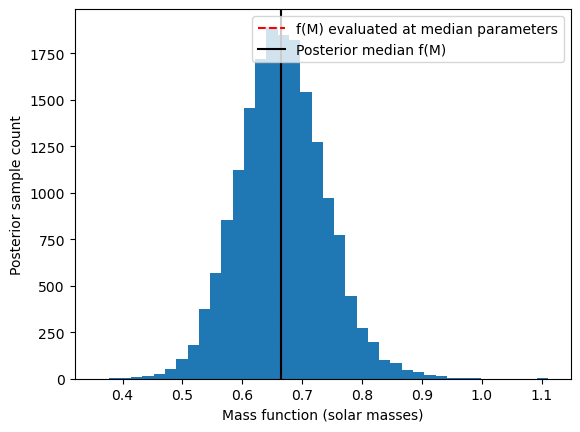

In [12]:
plt.hist(fm_samples, bins=40)
plt.axvline(fm_from_medians, color="red", linestyle="--",
            label="f(M) evaluated at median parameters")
plt.axvline(fm50, color="black", linestyle="-",
            label="Posterior median f(M)")
plt.xlabel("Mass function (solar masses)")
plt.ylabel("Posterior sample count")
plt.legend()
plt.show()

In [13]:
# Compare an early, short segment with the full chain
short_chain = sampler.get_chain(discard=100, flat=True)
full_chain = sampler.get_chain(discard=burn, thin=thin, flat=True)

parameter_names = ["P", "K", "e", "omega", "Tp", "gamma", "ln(s)"]

print("Short chain vs. full chain: median and 68% interval")
for j, name in enumerate(parameter_names):
    short_q = np.percentile(short_chain[:, j], [16, 50, 84])
    full_q = np.percentile(full_chain[:, j], [16, 50, 84])

    print(f"\n{name}")
    print(f"  Short: {short_q[1]:.4g} "
          f"(-{short_q[1]-short_q[0]:.3g}, +{short_q[2]-short_q[1]:.3g})")
    print(f"  Full:  {full_q[1]:.4g} "
          f"(-{full_q[1]-full_q[0]:.3g}, +{full_q[2]-full_q[1]:.3g})")

Short chain vs. full chain: median and 68% interval

P
  Short: 222.3 (-0.618, +0.673)
  Full:  222.3 (-0.611, +0.668)

K
  Short: 34.43 (-1.31, +1.34)
  Full:  34.42 (-1.31, +1.34)

e
  Short: 0.4544 (-0.0273, +0.0269)
  Full:  0.4543 (-0.0273, +0.0269)

omega
  Short: 2.639 (-0.0779, +0.0743)
  Full:  2.639 (-0.0792, +0.0749)

Tp
  Short: -25.84 (-2.66, +2.37)
  Full:  -25.85 (-2.67, +2.4)

gamma
  Short: -35.38 (-0.837, +0.814)
  Full:  -35.38 (-0.835, +0.812)

ln(s)
  Short: 1.17 (-0.229, +0.219)
  Full:  1.171 (-0.228, +0.217)


## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**

*your answer goes here*

**REFLECTION:**

*your answer goes here*

**VERIFICATION PLAN:**

Whether the mass function calculated sample-by-sample differs from calculating it at the median parameters.

Whether omitting jitter changes the best fit.

Whether the MCMC results are stable between shorter and longer portions of the chain.

Whether your full pipeline can recover known parameters from synthetic RV data.

f(M) at median parameters: 0.66399 solar masses
Posterior median f(M):     0.66447 solar masses
68% interval:              [0.59596, 0.73626] solar masses
Difference between estimates: -0.00047 solar masses


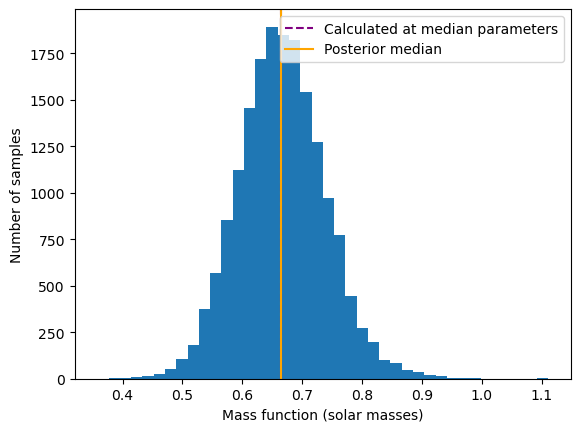

In [17]:
# Mass function evaluated at median orbital parameters
P_med, K_med, e_med = np.median(samples[:, :3], axis=0)
fm_at_medians = mass_function(P_med, K_med, e_med)

# Mass function calculated for every posterior sample
fm_samples = mass_function(samples[:, 0], samples[:, 1], samples[:, 2])
fm16, fm50, fm84 = np.percentile(fm_samples, [16, 50, 84])

print(f"f(M) at median parameters: {fm_at_medians:.5f} solar masses")
print(f"Posterior median f(M):     {fm50:.5f} solar masses")
print(f"68% interval:              [{fm16:.5f}, {fm84:.5f}] solar masses")
print(f"Difference between estimates: {fm_at_medians - fm50:.5f} solar masses")

plt.hist(fm_samples, bins=40)
plt.axvline(fm_at_medians, linestyle="--",
            label="Calculated at median parameters", color="purple")
plt.axvline(fm50, linestyle="-",
            label="Posterior median", color="orange")
plt.xlabel("Mass function (solar masses)")
plt.ylabel("Number of samples")
plt.legend()
plt.show()

In [18]:
from scipy.optimize import minimize

# Use the median posterior parameters as the starting point
theta_start = np.array([
    np.median(samples[:, 0]),  # P
    np.median(samples[:, 1]),  # K
    np.median(samples[:, 2]),  # e
    np.median(samples[:, 3]),  # omega
    np.median(samples[:, 4]),  # Tp
    np.median(samples[:, 5])   # gamma
])

s_med = np.median(samples[:, 6])

def nll_with_jitter(theta):
    P, K, e, omega, Tp, gamma = theta
    model = kepler_rv(t, P, K, e, omega, Tp, gamma)
    var = sig**2 + s_med**2
    return 0.5 * np.sum((rv - model)**2 / var + np.log(var))

def nll_without_jitter(theta):
    P, K, e, omega, Tp, gamma = theta
    if P <= 0 or K <= 0 or not 0 <= e < 1:
        return 1e100

    model = kepler_rv(t, P, K, e, omega, Tp, gamma)
    var = sig**2
    return 0.5 * np.sum((rv - model)**2 / var + np.log(var))

bounds = [
    (0.5 * theta_start[0], 1.5 * theta_start[0]),
    (0.001, max(5 * np.ptp(rv), 10)),
    (0.0, 0.95),
    (theta_start[3] - 2*np.pi, theta_start[3] + 2*np.pi),
    (t.min() - theta_start[0], t.max() + theta_start[0]),
    (rv.min() - np.ptp(rv), rv.max() + np.ptp(rv))
]

fit_no_jitter = minimize(
    nll_without_jitter,
    theta_start,
    method="Nelder-Mead",
    options={"maxiter": 10000}
)

# Compare both fits using the same six orbital parameters
fit_with_jitter = minimize(
    nll_with_jitter,
    theta_start,
    method="Nelder-Mead",
    options={"maxiter": 10000}
)

names6 = ["P (days)", "K (km/s)", "e", "omega (rad)", "Tp (days)", "gamma (km/s)"]

print(f"Median posterior jitter: {s_med:.3f} km/s")
print("\nParameter comparison:")
print(f"{'Parameter':<15} {'With jitter':>15} {'No jitter':>15} {'Difference':>15}")

for i, name in enumerate(names6):
    a = fit_with_jitter.x[i]
    b = fit_no_jitter.x[i]
    print(f"{name:<15} {a:>15.5g} {b:>15.5g} {b-a:>15.5g}")

print("\nNote: these are best-fit estimates, not posterior credible intervals.")

Median posterior jitter: 3.225 km/s

Parameter comparison:
Parameter           With jitter       No jitter      Difference
P (days)                 222.22          222.26        0.045635
K (km/s)                   34.6          35.501         0.90104
e                       0.45821         0.43669       -0.021522
omega (rad)              2.6464          2.6236        -0.02278
Tp (days)                -25.53          -25.92        -0.38911
gamma (km/s)            -35.413         -34.287          1.1265

Note: these are best-fit estimates, not posterior credible intervals.


Posterior comparison: first half vs. second half
Parameter     First median   Second median      Difference
P                    222.3          222.31        0.010223
K                   34.416          34.435        0.018876
e                   0.4539         0.45484      0.00093991
omega               2.6388           2.639       0.0001267
Tp                 -25.832         -25.835      -0.0035693
gamma              -35.372         -35.385       -0.012842
s                   3.2255          3.2204      -0.0051419


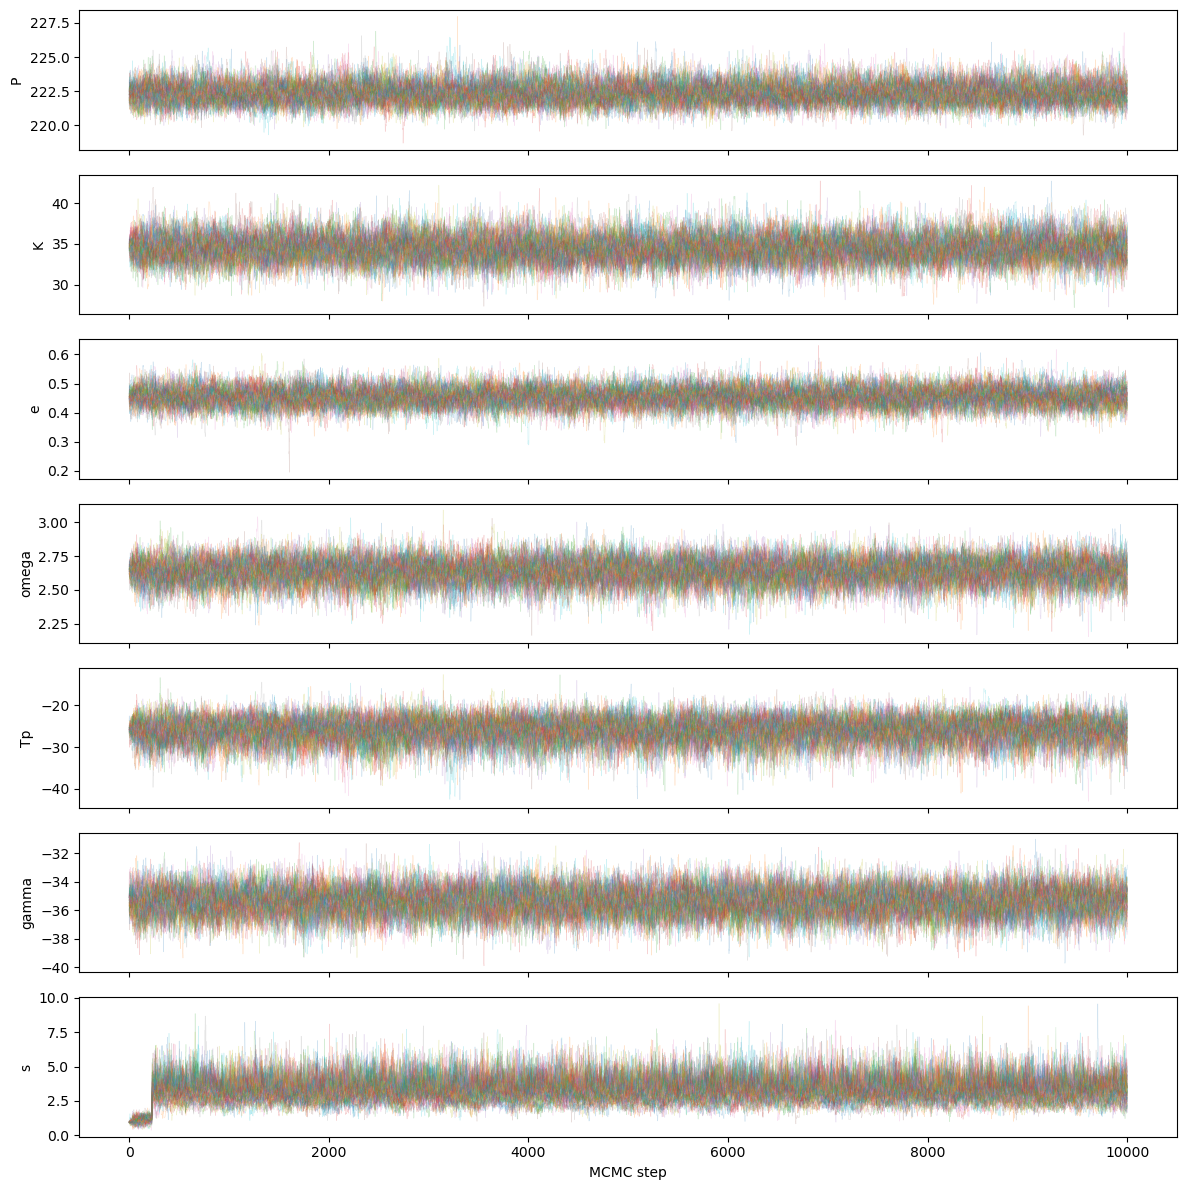

In [19]:
# sampler is your existing emcee sampler
chain = sampler.get_chain()  # shape: steps, walkers, parameters

mid = chain.shape[0] // 2

# Remove the burn-in from each half
first_start = min(burn, mid - 1)
second_start = max(mid, burn)

first_chain = chain[first_start:mid, :, :].reshape(-1, 7)
second_chain = chain[second_start:, :, :].reshape(-1, 7)

# Convert ln(s) to s, just as you did for your main samples
first_chain[:, 6] = np.exp(first_chain[:, 6])
second_chain[:, 6] = np.exp(second_chain[:, 6])

labels7 = ["P", "K", "e", "omega", "Tp", "gamma", "s"]

print("Posterior comparison: first half vs. second half")
print(f"{'Parameter':<10} {'First median':>15} {'Second median':>15} {'Difference':>15}")

for i, name in enumerate(labels7):
    first_med = np.median(first_chain[:, i])
    second_med = np.median(second_chain[:, i])
    print(f"{name:<10} {first_med:>15.5g} {second_med:>15.5g} "
          f"{second_med-first_med:>15.5g}")

# Plot the full chains to look for drift or stuck walkers
fig, axes = plt.subplots(7, 1, figsize=(12, 12), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], alpha=0.2, linewidth=0.4)
    ax.set_ylabel(labels7[i])
axes[-1].set_xlabel("MCMC step")
plt.tight_layout()
plt.show()

In [26]:
# Synthetic recovery test
# Run after defining kepler_rv(), log_posterior(), and your priors.

rng = np.random.default_rng(20261008)

# Save the original observed data
rv_observed = rv.copy()

# Pick known parameters near your fitted solution
truth = np.array([
    222.3,                         # P (days)
    34.42,                         # K (km/s)
    0.4543,                        # e
    np.median(samples[:, 3]),      # omega (rad)
    np.median(samples[:, 4]),      # Tp (days)
    -35.38,                        # gamma (km/s)
    3.225                          # jitter s (km/s)
])

P_true, K_true, e_true, omega_true, Tp_true, gamma_true, s_true = truth

# Generate a noiseless orbit at the actual observation times
rv_model_true = kepler_rv(
    t, P_true, K_true, e_true, omega_true, Tp_true, gamma_true
)

# Add realistic Gaussian noise using measurement uncertainty + jitter
rv_synthetic = rv_model_true + rng.normal(
    loc=0.0,
    scale=np.sqrt(sig**2 + s_true**2),
    size=len(t)
)

# Replace observed RV values temporarily
rv = rv_synthetic

# Start walkers near the known truth.
# The last parameter is ln(s), since log_posterior expects ln(s).
truth_log = truth.copy()
truth_log[6] = np.log(s_true)

scales_test = np.array([
    0.002 * P_true,
    0.01 * K_true,
    0.01,
    0.02,
    0.002 * P_true,
    0.01 * max(abs(gamma_true), 1),
    0.03
])

nwalkers_test = 64
nsteps_test = 6000
ndim_test = 7

pos_test[i] = truth_log + scales_test * rng.normal(size=ndim_test)

# Keep all initial walkers within the existing prior
for i in range(nwalkers_test):
    attempts = 0
    while not np.isfinite(log_posterior(pos_test[i])):
        pos_test[i] = truth_log + scales_test * rng.normal(ndim_test)
        attempts += 1
        if attempts > 10000:
            rv = rv_observed
            raise RuntimeError(
                "Could not initialize synthetic-test walkers within the prior."
            )

sampler_test = emcee.EnsembleSampler(
    nwalkers_test, ndim_test, log_posterior
)

try:
    sampler_test.run_mcmc(pos_test, nsteps_test)

    # Use an autocorrelation estimate to choose burn-in if possible
    try:
        tau_test = sampler_test.get_autocorr_time(tol=0)
        burn_test = min(int(3 * np.max(tau_test)), nsteps_test // 2)

        if nsteps_test < 50 * np.max(tau_test):
            print("WARNING: Synthetic chain may be too short for reliable recovery.")
    except emcee.autocorr.AutocorrError:
        burn_test = nsteps_test // 2
        print("WARNING: Could not estimate autocorrelation time reliably.")

    # Flatten and convert ln(s) to s
    test_samples = sampler_test.get_chain(
        discard=burn_test, flat=True
    )
    test_samples[:, 6] = np.exp(test_samples[:, 6])

finally:
    # Restore the real observations even if the test errors
    rv = rv_observed

# Compare true values with posterior 68% intervals
print("\nSynthetic-data recovery results")
print(f"{'Parameter':<10} {'Truth':>12} {'16th pct':>12} "
      f"{'Median':>12} {'84th pct':>12} {'Contains truth?':>16}")

for i, name in enumerate(labels7):
    q16, med, q84 = np.percentile(test_samples[:, i], [16, 50, 84])
    contained = q16 <= truth[i] <= q84
    print(f"{name:<10} {truth[i]:>12.5g} {q16:>12.5g} "
          f"{med:>12.5g} {q84:>12.5g} {str(contained):>16}")

# Count how many of the seven true values lie inside their 68% intervals
n_contained = sum(
    np.percentile(test_samples[:, i], 16)
    <= truth[i]
    <= np.percentile(test_samples[:, i], 84)
    for i in range(7)
)

print(f"\nTruth inside 68% interval for {n_contained}/7 parameters.")


Synthetic-data recovery results
Parameter         Truth     16th pct       Median     84th pct  Contains truth?
P                 222.3       221.07       221.55       222.05            False
K                 34.42       35.588       36.877       38.208            False
e                0.4543      0.46153      0.48505      0.50798            False
omega            2.6387       2.6267       2.6876       2.7456             True
Tp              -25.847      -24.102      -22.306      -20.668            False
gamma            -35.38      -35.155      -34.411      -33.661            False
s                 3.225       2.1841       2.8536       3.6289             True

Truth inside 68% interval for 2/7 parameters.


 The synthetic data recovery did not recover all fo the input parameters with 68% intervals, with only two of the seven parameters getting their values. Possible explanations to this could include random noise introduced from the Gussian, non convging MCMC values, or bad parameters. While this test does not exactly show the strongest model, more investigation would be needed to test these ideas.